# **Import Required Libraries**

**NumPy & Matplotlib**: For numerical computations and plotting.

**Scikit-learn:** For dataset loading and splitting data into training, validation, and test sets.

**TensorFlow/Keras:** For building, training, and evaluating the neural network model.

**2. Helper Function for Plotting Metrics plot_metrics:** Plots training and validation loss and accuracy over epochs to visualize the model's performance during training.


3.** Load and Preprocess the Iris Dataset**

Dataset:The Iris dataset is loaded using load_iris() from scikit-learn.
**X_iris:** Contains the features (e.g., petal length, sepal width).
**y_iris:** Contains the target class (species of Iris), one-hot encoded using to_categorical.
Split Data: The dataset is divided into:
Training Set: Used to train the model (80% of the total data).
Validation Set: Used to tune the model during training.
Test Set: Used to evaluate final model performance on unseen data.

4. **Build the Neural Network Model Structure:**
Input Layer: Matches the number of features in the dataset (X_iris.shape[1] = 4).
Hidden Layers: Two layers with 10 and 16 neurons respectively, using ReLU activation.
Output Layer: Three neurons (corresponding to the 3 Iris species) with softmax activation for multi-class classification.
Compilation:
Optimizer: adam (adaptive learning rate optimization).
Loss: categorical_crossentropy (used for multi-class classification).
Metrics: accuracy to monitor during training.

5. **Train the Model Training Process:**
fit: The model is trained for 50 epochs with a batch size of 8.
Training data is used for learning, and validation data is used to monitor generalization during training.

6. Evaluate the Model
After training, the model is evaluated on the test set to measure its performance (loss and accuracy) on unseen data.

7. Plot Metrics
Training and validation loss and accuracy are plotted over epochs using plot_metrics, providing insights into:
Overfitting: If validation loss increases while training loss decreases.
Convergence: Whether both losses stabilize over epochs.
Outputs
Final test loss and accuracy.
Graphical plots showing the model's training and validation performance over time.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


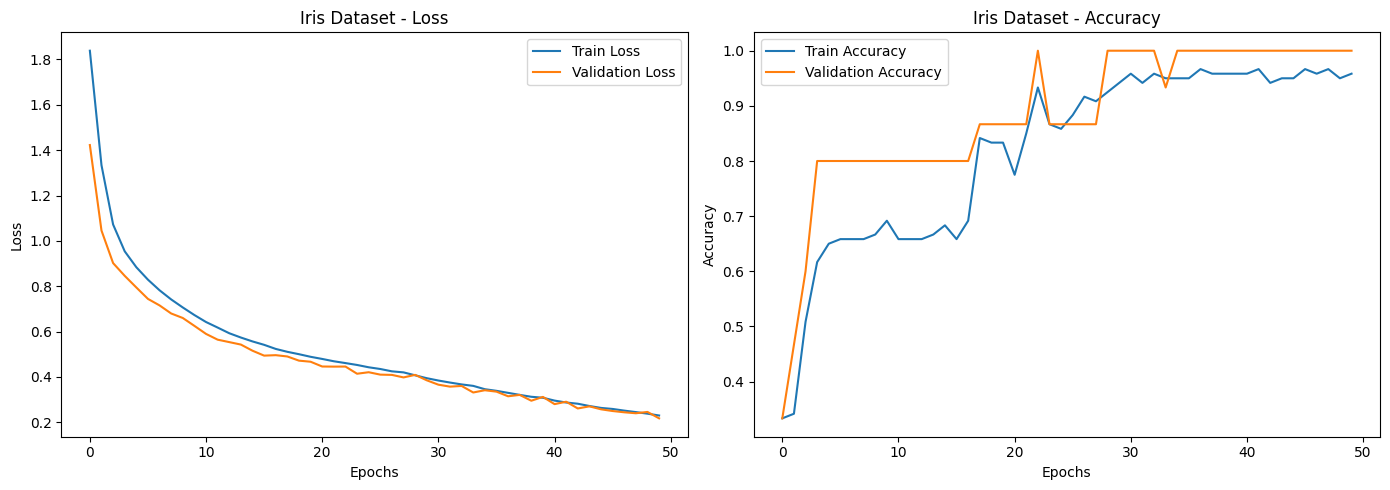

In [2]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Helper function to plot metrics
def plot_metrics(history, title="Model Metrics"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Plot loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Plot accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# Load and preprocess Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = to_categorical(iris.target)

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Build the modified neural network
model_iris = Sequential([
    Dense(10, input_shape=(X_iris.shape[1],), activation='relu'),
    Dense(16, activation='relu'),  # Additional hidden layer
    Dense(3, activation='softmax')
])

model_iris.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history_iris = model_iris.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate the model
test_loss_iris, test_accuracy_iris = model_iris.evaluate(X_test, y_test, verbose=0)

# Plot metrics
plot_metrics(history_iris, title="Iris Dataset")

# **Part 2: Neural Network on Wine Dataset**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


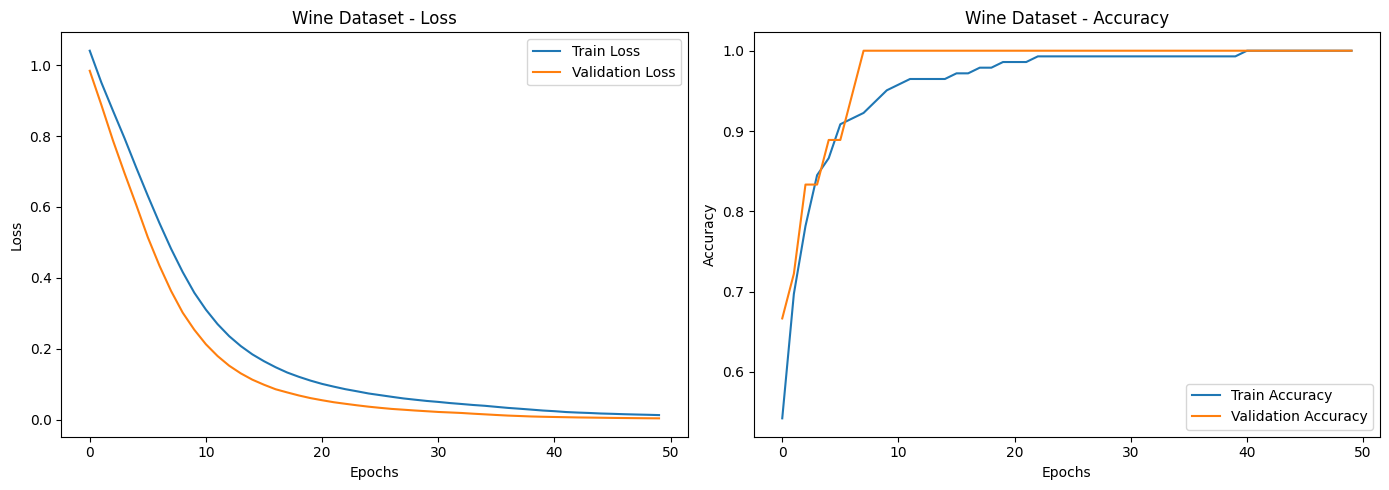

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


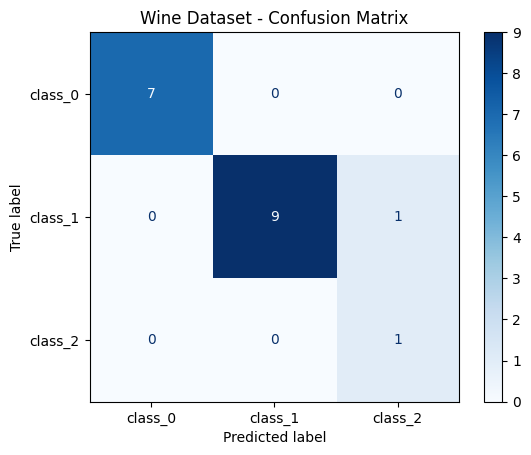

In [3]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load and preprocess Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = to_categorical(wine.target)

scaler = StandardScaler()
X_wine = scaler.fit_transform(X_wine)

X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Build the neural network for Wine dataset
model_wine = Sequential([
    Dense(8, input_shape=(X_wine.shape[1],), activation='relu'),
    Dense(16, activation='relu'),  # Second hidden layer
    Dense(3, activation='softmax')
])

model_wine.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history_wine = model_wine.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=8, verbose=0)

# Evaluate the model
test_loss_wine, test_accuracy_wine = model_wine.evaluate(X_test, y_test, verbose=0)

# Plot metrics
plot_metrics(history_wine, title="Wine Dataset")

# Confusion matrix for test predictions
y_pred_wine = model_wine.predict(X_test).argmax(axis=1)
y_true_wine = y_test.argmax(axis=1)
disp = ConfusionMatrixDisplay(confusion_matrix(y_true_wine, y_pred_wine), display_labels=wine.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Wine Dataset - Confusion Matrix")
plt.show()